<a href="https://colab.research.google.com/github/SaavedraLuana/hair-lightening-analytics/blob/main/hair_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌻 Hair Lightening Analytics

This notebook explores data from my personal hair-lightening journey using Python, Pandas, and Matplotlib.

The analysis combines information about hair condition, lightening treatments, products, and progress over time.

## Goals

- Explore and clean the collected data
- Analyze the products used in my routine
- Track hair condition and lightening progress
- Identify patterns as more observations are collected
- Practice data analysis and visualization with Python

## 1. Data Loading

Importing the libraries and loading the datasets directly from the GitHub repository.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/SaavedraLuana/hair-lightening-analytics/main/data/hair_observations.csv"

hair = pd.read_csv(url)

hair

,date,hair_area,lightening_level,dryness,softness,shine,curl_definition,breakage,satisfaction,condition_context,notes
0,2026-07-24,Nape,1.0,2,NaN,3,NaN,NaN,3.0,Initial observation,Initial observation recorded at the nape
1,2026-09-15,Full hair,NaN,4,2.0,3,1.0,1.0,NaN,After overnight deep conditioning,Hair assessed after overnight conditioning wit...


## 2. Data Quality & Preparation

Checking the structure, data types, and missing values before starting the analysis.

In [4]:
hair.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               2 non-null      object 
 1   hair_area          2 non-null      object 
 2   lightening_level   1 non-null      float64
 3   dryness            2 non-null      int64  
 4   softness           1 non-null      float64
 5   shine              2 non-null      int64  
 6   curl_definition    1 non-null      float64
 7   breakage           1 non-null      float64
 8   satisfaction       1 non-null      float64
 9   condition_context  2 non-null      object 
 10  notes              2 non-null      object 
dtypes: float64(5), int64(2), object(4)
memory usage: 308.0+ bytes


In [5]:
hair["date"] = pd.to_datetime(hair["date"])

hair.dtypes

,0
date,datetime64[ns]
hair_area,object
lightening_level,float64
dryness,int64
softness,float64
shine,int64
curl_definition,float64
breakage,float64
satisfaction,float64
condition_context,object


In [9]:
base_url = "https://raw.githubusercontent.com/SaavedraLuana/hair-lightening-analytics/main/data/"

lightening = pd.read_csv(base_url + "lightening_log.csv")
photos = pd.read_csv(base_url + "photo_log.csv")
products = pd.read_csv(base_url + "products.csv")
treatments = pd.read_csv(base_url + "treatment_log.csv")

In [8]:
products_url = base_url + "products.csv"

products = pd.read_csv(products_url, on_bad_lines="warn")
products

/tmp/ipykernel_1961/3182232352.py:3: ParserWarning: Skipping line 3: expected 13 fields, saw 14

  products = pd.read_csv(products_url, on_bad_lines="warn")


,id,name,brand,product_type,active_ingredients,concentration,use_frequency,start_date,end_date,price,notes,rating,image_path
0,1,OxiLift Bleach,ExampleBrand,bleach,ammonium persulfate,10 vol,every 6 weeks,2025-12-01,NaN,12.99,Left on 25 min; minor breakage,4,images/oxilift.jpg
1,3,SoftTone Toner,ExampleBrand,toner,ultraviolet violet pigment,NaN,as needed,2026-01-10,NaN,9.99,Neutralizes brassiness,4,images/softtone.jpg
2,4,BondFix Treatment,RepairCo,bond-builder,cysteamine,crosslinker,weekly,2026-02-01,NaN,24.99,Use 1-2 times/week after washing,5,images/bondfix.jpg
3,5,Garnier Elixir Iluminador (serum aclarante pro...,Garnier,serum,NaN,NaN,NaN,"2x per week (day, dried in sun)",NaN,NaN,Used during day and drying under the sun; caus...,NaN,images/garnier_elixir.jpg
4,6,Loción Spray Reflejos Rubios,Garnier,spray,NaN,NaN,NaN,1x per week,NaN,NaN,Opens the hair colour; used once per week,NaN,images/locion_reflejos.jpg
5,7,Herbal Bionature Rizos Bounce Cream,Herbal Bionature,cream,NaN,NaN,NaN,daily,NaN,NaN,Moisturizes and keeps curls; everyday use,NaN,images/bionature_bounce.jpg
6,8,Herbal Bionature Curl Activator Gel,Herbal Bionature,gel,NaN,NaN,NaN,3x per week,NaN,NaN,Curl activator gel; 3x/week use,NaN,images/bionature_gel.jpg
7,9,Garnier Fructis Nutri Rizos Hidra Caracois Cre...,Garnier Fructis,cream,NaN,NaN,NaN,daily,NaN,NaN,Defines and preserves curls; everyday use,NaN,images/garnier_fructis.jpg
8,10,Revlon Flex Definicion del Rizo Acondicionador...,Revlon,conditioner,NaN,NaN,NaN,daily,NaN,NaN,Helps with detangling; everyday use,NaN,images/revlon_definicion.jpg
9,11,Be Beauty Argan Oil Hair Serum,Be Beauty,serum,argan oil,NaN,3x per week (night),NaN,NaN,Argan oil serum; 3x/week at night,NaN,images/be_beauty_argan.jpg,NaN


In [10]:
print("Hair observations:", hair.shape)
print("Lightening log:", lightening.shape)
print("Photo log:", photos.shape)
print("Products:", products.shape)
print("Treatment log:", treatments.shape)

Hair observations: (2, 11)
Lightening log: (2, 7)
Photo log: (6, 6)
Products: (12, 13)
Treatment log: (2, 7)


In [11]:
products[["name", "brand", "product_type", "use_frequency"]]

,name,brand,product_type,use_frequency
0,OxiLift Bleach,ExampleBrand,bleach,every 6 weeks
1,ProDev Developer,ExampleBrand,developer,with bleach
2,SoftTone Toner,ExampleBrand,toner,as needed
3,BondFix Treatment,RepairCo,bond-builder,weekly
4,Garnier Elixir Iluminador (serum aclarante pro...,Garnier,serum,NaN
5,Loción Spray Reflejos Rubios,Garnier,spray,NaN
6,Herbal Bionature Rizos Bounce Cream,Herbal Bionature,cream,NaN
7,Herbal Bionature Curl Activator Gel,Herbal Bionature,gel,NaN
8,Garnier Fructis Nutri Rizos Hidra Caracois Cre...,Garnier Fructis,cream,NaN
9,Revlon Flex Definicion del Rizo Acondicionador...,Revlon,conditioner,NaN


## 3. Product Analysis

Exploring the types of products included in the hair-care and lightening dataset.

In [12]:
product_type_counts = products["product_type"].value_counts()

product_type_counts

,count
product_type,
cream,2
serum,2
developer,1
bleach,1
bond-builder,1
toner,1
spray,1
gel,1
conditioner,1


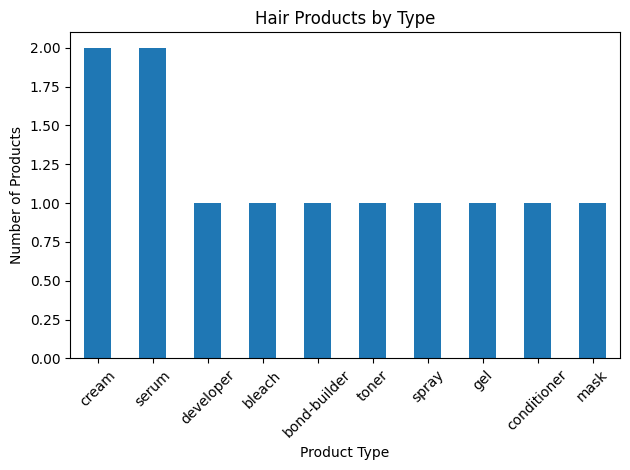

In [13]:
product_type_counts.plot(kind="bar")

plt.title("Hair Products by Type")
plt.xlabel("Product Type")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Product Distribution by Brand

This analysis shows how the products in the dataset are distributed across different brands.

In [14]:
brand_counts = products["brand"].value_counts()

brand_counts

,count
brand,
ExampleBrand,3
Garnier,2
Herbal Bionature,2
RepairCo,1
Garnier Fructis,1
Revlon,1
Be Beauty,1
Deliplus,1


In [15]:
products[products["brand"].isin(["ExampleBrand", "RepairCo"])]

,id,name,brand,product_type,active_ingredients,concentration,use_frequency,start_date,end_date,price,notes,rating,image_path
0,1,OxiLift Bleach,ExampleBrand,bleach,ammonium persulfate,10 vol,every 6 weeks,2025-12-01,NaN,12.99,Left on 25 min; minor breakage,4,images/oxilift.jpg
1,2,ProDev Developer,ExampleBrand,developer,hydrogen peroxide,20 vol,with bleach,2025-12-01,NaN,6.50,NaN,5,images/prodev.jpg
2,3,SoftTone Toner,ExampleBrand,toner,ultraviolet violet pigment,NaN,as needed,2026-01-10,NaN,9.99,Neutralizes brassiness,4,images/softtone.jpg
3,4,BondFix Treatment,RepairCo,bond-builder,cysteamine,crosslinker,weekly,2026-02-01,NaN,24.99,Use 1-2 times/week after washing,5,images/bondfix.jpg


In [16]:
products_clean = products[
    ~products["brand"].isin(["ExampleBrand", "RepairCo"])
].copy()

products_clean[["name", "brand", "product_type", "use_frequency"]]

,name,brand,product_type,use_frequency
4,Garnier Elixir Iluminador (serum aclarante pro...,Garnier,serum,NaN
5,Loción Spray Reflejos Rubios,Garnier,spray,NaN
6,Herbal Bionature Rizos Bounce Cream,Herbal Bionature,cream,NaN
7,Herbal Bionature Curl Activator Gel,Herbal Bionature,gel,NaN
8,Garnier Fructis Nutri Rizos Hidra Caracois Cre...,Garnier Fructis,cream,NaN
9,Revlon Flex Definicion del Rizo Acondicionador...,Revlon,conditioner,NaN
10,Be Beauty Argan Oil Hair Serum,Be Beauty,serum,3x per week (night)
11,Deliplus Repair e Nutrition Mask,Deliplus,mask,NaN


In [17]:
clean_type_counts = products_clean["product_type"].value_counts()

clean_type_counts

,count
product_type,
serum,2
cream,2
spray,1
gel,1
conditioner,1
mask,1


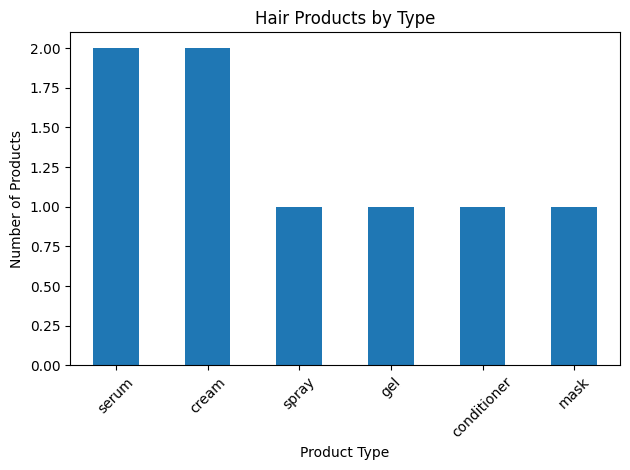

In [18]:
clean_type_counts.plot(kind="bar")

plt.title("Hair Products by Type")
plt.xlabel("Product Type")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [19]:
condition_metrics = hair[
    ["date", "dryness", "softness", "shine", "curl_definition", "breakage"]
]

condition_metrics

,date,dryness,softness,shine,curl_definition,breakage
0,2026-07-24,2,NaN,3,NaN,NaN
1,2026-09-15,4,2.0,3,1.0,1.0


In [20]:
condition_metrics.isna().sum()

,0
date,0
dryness,0
softness,1
shine,0
curl_definition,1
breakage,1


In [21]:
comparison = hair[
    ["date", "dryness", "shine"]
].copy()

comparison

,date,dryness,shine
0,2026-07-24,2,3
1,2026-09-15,4,3


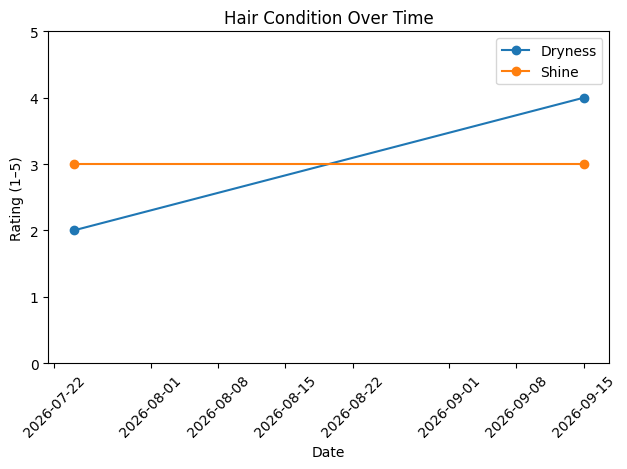

In [22]:
plt.plot(comparison["date"], comparison["dryness"], marker="o", label="Dryness")
plt.plot(comparison["date"], comparison["shine"], marker="o", label="Shine")

plt.title("Hair Condition Over Time")
plt.xlabel("Date")
plt.ylabel("Rating (1–5)")
plt.ylim(0, 5)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Insight

Between July and September, the recorded dryness level increased from 2 to 4, while shine remained stable at 3.

This may indicate increased dryness during the hair-lightening process. However, the dataset currently contains only two comparable observations, so more data is needed before identifying a reliable trend.

In [23]:
print("LIGHTENING LOG")
display(lightening)

print("\nTREATMENT LOG")
display(treatments)

LIGHTENING LOG


,date,product,hair_area,frequency_or_status,lightening_level,dryness_level,notes
0,2026-09-15,Garnier Elixir,Front,Resumed after approximately 2-week break,NaN,NaN,Front is slightly lighter; currently focusing ...
1,2026-09-15,Chamomile Spray,Varies,1-2 times per week,NaN,NaN,Used as part of the highlighting routine; freq...



TREATMENT LOG


,date,treatment_type,hair_area,products,duration,purpose,observation
0,2026-09-15,Deep conditioning,Full hair,Dabur Amla Hair Oil; Coconut Oil; Olive Oil Mo...,Overnight,Moisture and recovery,Deep conditioning after experiencing dryness d...
1,2026-09-20,Heat styling,Full hair,Blow dryer; Flat iron,Same day,Visual inspection and styling,Hair was blow-dried and straightened with a fl...


In [24]:
lightening["date"] = pd.to_datetime(lightening["date"])
treatments["date"] = pd.to_datetime(treatments["date"])

print(lightening["date"].dtype)
print(treatments["date"].dtype)

datetime64[ns]
datetime64[ns]


In [25]:
merged_data = pd.merge(
    lightening,
    treatments,
    on="date",
    how="left",
    suffixes=("_lightening", "_treatment")
)

merged_data

,date,product,hair_area_lightening,frequency_or_status,lightening_level,dryness_level,notes,treatment_type,hair_area_treatment,products,duration,purpose,observation
0,2026-09-15,Garnier Elixir,Front,Resumed after approximately 2-week break,NaN,NaN,Front is slightly lighter; currently focusing ...,Deep conditioning,Full hair,Dabur Amla Hair Oil; Coconut Oil; Olive Oil Mo...,Overnight,Moisture and recovery,Deep conditioning after experiencing dryness d...
1,2026-09-15,Chamomile Spray,Varies,1-2 times per week,NaN,NaN,Used as part of the highlighting routine; freq...,Deep conditioning,Full hair,Dabur Amla Hair Oil; Coconut Oil; Olive Oil Mo...,Overnight,Moisture and recovery,Deep conditioning after experiencing dryness d...


In [26]:
analysis_view = merged_data[
    [
        "date",
        "product",
        "hair_area_lightening",
        "frequency_or_status",
        "treatment_type",
        "hair_area_treatment",
        "purpose"
    ]
]

analysis_view

,date,product,hair_area_lightening,frequency_or_status,treatment_type,hair_area_treatment,purpose
0,2026-09-15,Garnier Elixir,Front,Resumed after approximately 2-week break,Deep conditioning,Full hair,Moisture and recovery
1,2026-09-15,Chamomile Spray,Varies,1-2 times per week,Deep conditioning,Full hair,Moisture and recovery


In [27]:
treatments_by_date = treatments.groupby("date")["treatment_type"].count()

treatments_by_date

,treatment_type
date,
2026-09-15,1
2026-09-20,1


In [28]:
treatment_counts = treatments["treatment_type"].value_counts()

treatment_counts

,count
treatment_type,
Deep conditioning,1
Heat styling,1


## Key Insights

- The dataset currently contains two recorded treatment sessions: one deep-conditioning treatment and one heat-styling session.
- Deep conditioning was recorded on September 15 as part of the moisture and recovery routine.
- The lightening log shows two active approaches on September 15: Garnier Elixir and chamomile spray.
- Garnier Elixir was resumed after an approximately two-week break, while chamomile spray was being used 1–2 times per week.
- Hair dryness increased from 2 to 4 between the two recorded condition observations, while shine remained stable at 3.
- Because the condition dataset currently contains only two observations, these changes should not yet be interpreted as a reliable long-term trend.
- Continued data collection will allow future analysis of the relationship between lightening routines, treatments, dryness, breakage, curl definition, and overall hair condition.